In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [8]:
statue = cv.imread('../../../class.vision/images/statue.png', 0)
statue_bgr = cv.imread('../../../class.vision/images/statue.png')

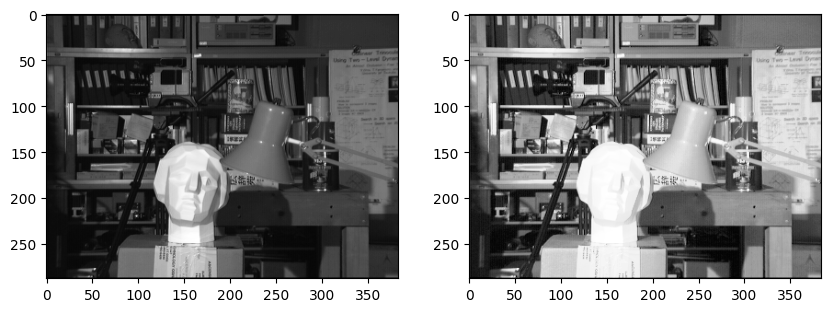

In [5]:
equalizedStatue = cv.equalizeHist(statue)
plt.figure(figsize=(10,6))
plt.subplot(121);plt.imshow(statue, cmap='gray')
plt.subplot(122);plt.imshow(equalizedStatue, cmap='gray')

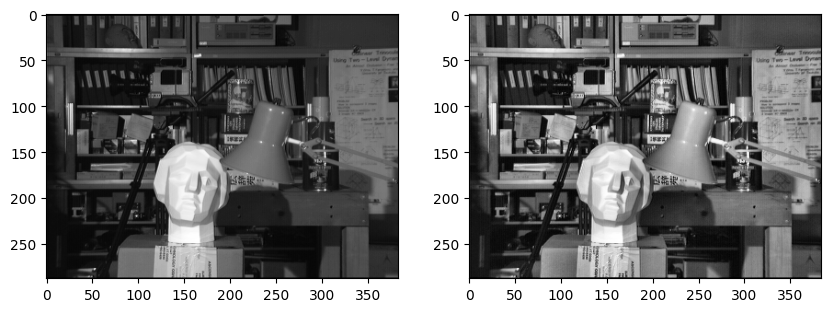

In [7]:
clahe = cv.createCLAHE(tileGridSize=(8, 8), clipLimit=2.0)
result = clahe.apply(statue)
plt.figure(figsize=(10,6))
plt.subplot(121);plt.imshow(statue, cmap='gray')
plt.subplot(122);plt.imshow(result, cmap='gray')

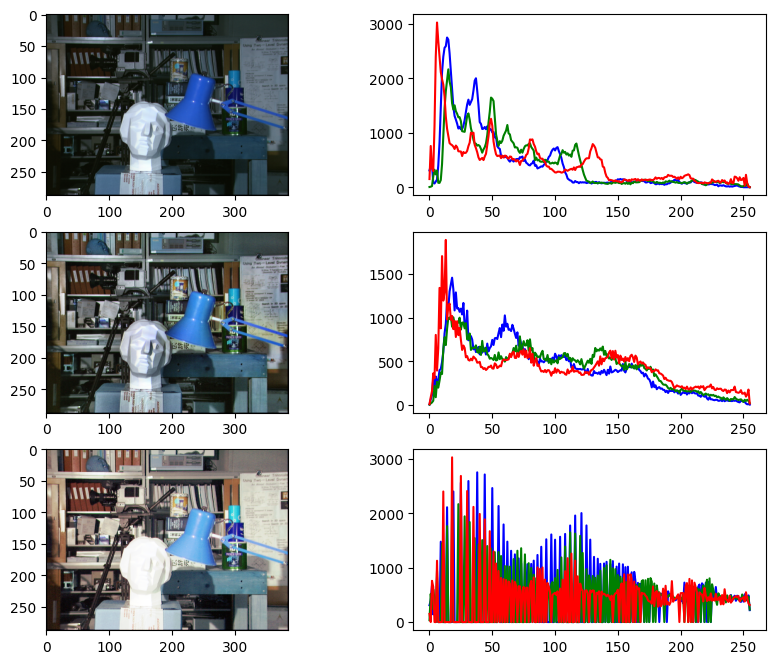

In [12]:
channels = ('b', 'g', 'r')
clahe = cv.createCLAHE(tileGridSize=(8, 8), clipLimit=2.0)
plt.figure(figsize=(10,8))


plt.subplot(322)
for idx, channel in enumerate(channels):
    hist = cv.calcHist([statue_bgr],[idx],None,[256],[0,256])
    plt.plot(hist, color=channel)

temp = []
plt.subplot(324)
for idx, channel in enumerate(channels):
    new_c = clahe.apply(statue_bgr[:,:,idx])
    temp.append(new_c)
    hist = cv.calcHist([new_c],[0],None,[256],[0,256])
    plt.plot(hist, color=channel)

result1 = cv.merge(temp)

temp = []
plt.subplot(326)
for idx, channel in enumerate(channels):
    new_c = cv.equalizeHist(statue_bgr[:,:,idx])
    temp.append(new_c)
    hist = cv.calcHist([new_c],[0],None,[256],[0,256])
    plt.plot(hist, color=channel)

result2 = cv.merge(temp)

plt.subplot(321);plt.imshow(statue_bgr[...])
plt.subplot(323);plt.imshow(result1[...])
plt.subplot(325);plt.imshow(result2[...])